# STT Model and Training

The next stage in the machine learning life cycle is modelling. In this tutorial we will use and fine-tune a pretrained STT model to improve performance on our data.

https://huggingface.co/blog/fine-tune-whisper

To run this notebook, you will need to download [PyTorch](https://pytorch.org/get-started/locally/).

Installation on Linux/WSL is easy, simply do `pip install torch`

If you are on Windows, make sure to add the CUDA version that corresponds to your GPU version:

`pip install torch --index-url https://download.pytorch.org/whl/cu126`

In [3]:
from datasets import load_dataset, Audio, DatasetDict

## 1. Prepare Dataset

### Load the dataset with Huggingface datasets

_Extra question: what is a parquet file?_

In [4]:
train_dataset = load_dataset('parquet', data_files='../dataset/train.parquet')
test_dataset = load_dataset('parquet', data_files='../dataset/test.parquet')
combined_dataset = DatasetDict({
    'train': train_dataset['train'],
    'test': test_dataset['train']})

In [5]:
combined_dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'audio', 'text', 'segment_start_time', 'segment_end_time', 'duration'],
        num_rows: 783
    })
    test: Dataset({
        features: ['id', 'audio', 'text', 'segment_start_time', 'segment_end_time', 'duration'],
        num_rows: 88
    })
})

a. How do you access the first row of the train_dataset from combined_dataset?

What is the format of the audio column?

In [6]:
# Hint: combined_dataset["train"]
combined_dataset["train"][0]

{'id': 'atco2_test-set-1h_LSZB_BERN_Tower_121_0MHz_20210420_090730-B__000000-000192',
 'audio': {'bytes': b'RIFF$\xf0\x00\x00WAVEfmt \x10\x00\x00\x00\x01\x00\x01\x00\x80>\x00\x00\x00}\x00\x00\x02\x00\x10\x00data\x00\xf0\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\

How is the audio data currently stored? Is it useful?

Answer: The audio is stored as raw bytes (a binary blob). This is not directly useful — we need it decoded into a numpy array of float samples at a known sampling rate.

### Format the audio column

_Extra question: how does the huggingface Audio column work?_

In [7]:
combined_dataset = combined_dataset.cast_column("audio", Audio(sampling_rate=16000))

What is the format of the audio column now?

In [8]:
combined_dataset["train"][0]["audio"]

{'path': None,
 'array': array([0.        , 0.        , 0.        , ..., 0.61425781, 0.61920166,
        0.6211853 ], shape=(30720,)),
 'sampling_rate': 16000}

Answer: The audio column is now a dict with keys `array` (a float32 numpy array of samples), `sampling_rate` (16000), and `path`. It has been automatically decoded and resampled to 16 kHz.

### Feature Extraction

We need to convert the audio into log-mel spectrogram and the text into tokens.

In [9]:
from transformers import WhisperFeatureExtractor, WhisperTokenizer

feature_extractor = WhisperFeatureExtractor.from_pretrained("openai/whisper-small")
tokenizer = WhisperTokenizer.from_pretrained("openai/whisper-small", language="English", task="transcribe")

b. Tokenize an input string

In [10]:
input_str = combined_dataset["train"][0]["text"]
input_str

'number one in sight hotel golf oscar'

In [11]:
# use the tokenizer to tokenize input_str, get only the input_ids
labels = tokenizer(input_str).input_ids
labels

[50258,
 50259,
 50359,
 50363,
 41261,
 472,
 294,
 7860,
 7622,
 12880,
 3003,
 6166,
 50257]

In [12]:
# decode the labels back into text
# hint: tokenizer.decode
decoded = tokenizer.decode(labels)
decoded

'<|startoftranscript|><|en|><|transcribe|><|notimestamps|>number one in sight hotel golf oscar<|endoftext|>'

_Extra question: what do the added tokens mean?_

In [13]:
# decode the labels, without special tokens
# hint: skip_special_tokens=True
decoded_no_special = tokenizer.decode(labels, skip_special_tokens=True)
decoded_no_special

'number one in sight hotel golf oscar'

c. Process an input audio

In [14]:
input_audio = combined_dataset["train"][0]["audio"]["array"]
input_audio.shape

(30720,)

In [15]:
# use the feature_extractor to get the input features
# hint: .input_features
features = feature_extractor(input_audio, sampling_rate=16000).input_features
features.shape

(1, 80, 3000)

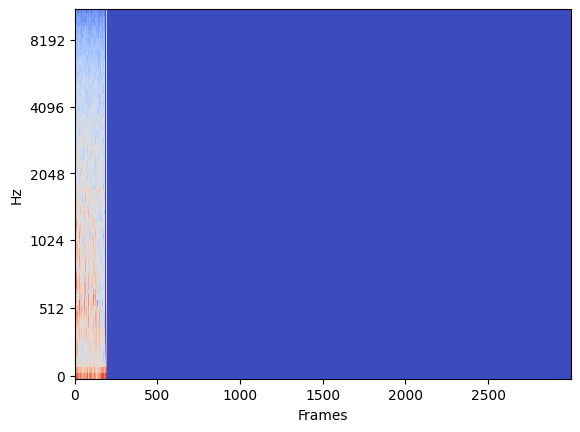

In [16]:
# plot the resulting features
import librosa

librosa.display.specshow(features[0], y_axis="mel", x_axis="frames")

Why is the majority of the diagram empty?

How many frames are there?

If Whisper's chunk length is 30s, what is the time difference between 2 frames?

Hence, deduce what the feature extractor is doing.

WhisperProcessor is a wrapper around both the tokenizer and feature extractor.

In [17]:
from transformers import WhisperProcessor

processor = WhisperProcessor.from_pretrained("openai/whisper-small", language="English", task="transcribe")

In [18]:
def prepare_dataset(batch):
    # load and resample audio data from 48 to 16kHz
    audio = batch["audio"]

    # compute log-Mel input features from input audio array 
    batch["input_features"] = feature_extractor(audio["array"], sampling_rate=audio["sampling_rate"]).input_features[0]

    # encode target text to label ids 
    batch["labels"] = tokenizer(batch["text"]).input_ids
    return batch

Apply processing to the entire dataset

In [19]:
combined_dataset = combined_dataset.map(prepare_dataset, remove_columns=combined_dataset.column_names["train"])

## 2. Model

Now we will use the Whisper small model to predict our data.

In [20]:
from transformers import WhisperForConditionalGeneration

model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-small")

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

While Whisper can infer the task and language, it is good to explicitly set them when training.

In [21]:
model.generation_config.language = "English"
model.generation_config.task = "transcribe"

model.generation_config.forced_decoder_ids = None

Data collator is a helper class that applies whisper preprocessing to both audio and text.

In [22]:
import torch

from dataclasses import dataclass
from typing import Any, Dict, List, Union

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any
    decoder_start_token_id: int

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        # split inputs and labels since they have to be of different lengths and need different padding methods
        # first treat the audio inputs by simply returning torch tensors
        input_features = [{"input_features": feature["input_features"]} for feature in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")

        # get the tokenized label sequences
        label_features = [{"input_ids": feature["labels"]} for feature in features]
        # pad the labels to max length
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")

        # replace padding with -100 to ignore loss correctly
        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)

        # if bos token is appended in previous tokenization, strip it
        if (labels[:, 0] == self.decoder_start_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch["labels"] = labels

        return batch

In [23]:
data_collator = DataCollatorSpeechSeq2SeqWithPadding(
    processor=processor,
    decoder_start_token_id=model.config.decoder_start_token_id,
)

Define the calculation of Word Error Rate

What is the standard loss function for STT models? Hence, why do we need to define a custom metric?

In [24]:
import evaluate

metric = evaluate.load("wer")

In [25]:
def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    # replace -100 with the pad_token_id
    label_ids[label_ids == -100] = tokenizer.pad_token_id

    # we do not want to group tokens when computing the metrics
    pred_str = tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    wer = 100 * metric.compute(predictions=pred_str, references=label_str)

    return {"wer": wer}

## 3. Training

### Specify training parameters.

What is the difference between steps and epochs?

What do save_steps and eval_steps mean? Change save_steps and eval_steps to match max_steps.

How much v-ram does this require? Tinker with the training arguments to reduce it.

In [26]:
from transformers import Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(
    output_dir="./whisper-small-en",
    per_device_train_batch_size=16,
    gradient_accumulation_steps=1,  # increase by 2x for every 2x decrease in batch size
    learning_rate=1e-5,
    warmup_steps=50,
    max_steps=500,
    gradient_checkpointing=True,
    fp16=True,
    eval_strategy="steps",
    per_device_eval_batch_size=8,
    predict_with_generate=True,
    generation_max_length=225,
    save_steps=500,   # changed to match max_steps
    eval_steps=500,   # changed to match max_steps
    logging_steps=25,
    report_to=["tensorboard"],
    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,
    remove_unused_columns=True
)

In [28]:
from transformers import Seq2SeqTrainer

trainer = Seq2SeqTrainer(
    args=training_args,
    model=model,
    train_dataset=combined_dataset["train"],
    eval_dataset=combined_dataset["test"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

### Initial zero-shot evaluation

In [29]:
pred = trainer.predict(combined_dataset["test"])

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensA

In [30]:
# Print the metrics
# hint: compute_metrics
compute_metrics(pred)

{'wer': 87.00460829493088}

Example ground truth vs prediction

In [31]:
# Ground truth
tokenizer.decode(combined_dataset["test"][0]["labels"], skip_special_tokens=True)

'oscar oscar papa charlie kilo it s for ifr fly to echo bravo charlie india we have information delta it is for startup and ifr clearance'

In [32]:
# Prediction
tokenizer.decode(pred.predictions[0], skip_special_tokens=True)

' Oscar Oscar Papa Charlie kill it for IFR flight to Ecopravo Charlie India we have information Delta is for start and IFR clearance'

### Train model

Train the model using the specified training arguments

In [34]:
trainer.train()

Step,Training Loss,Validation Loss,Model Preparation Time,Wer
500,0.001387,0.570614,0.003700,19.539171


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['proj_out.weight'].


TrainOutput(global_step=500, training_loss=0.24002579912543298, metrics={'train_runtime': 1015.3727, 'train_samples_per_second': 7.879, 'train_steps_per_second': 0.492, 'total_flos': 2.3057973485568e+18, 'train_loss': 0.24002579912543298, 'epoch': 10.204081632653061})

Save the best model in the output directory for future use.

_Extra question: where can you access the saved model checkpoints?_

In [35]:
import os

output_dir = './whisper-small-trained'
os.makedirs(output_dir, exist_ok=True)
processor.save_pretrained(output_dir)
trainer.save_model(output_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## 4. Evaluation

Finally, we can evaluate WER on test data. In this case, we still use the test split.

_Extra question: We're using the same split (test) for training evaluation and final evaluation. What are some downsides of this?_

In [ ]:
trainer.evaluate(combined_dataset["test"])

How much did the performance improve by after training?

Overall, was the training effective?